In [62]:
import pandas as pd
import numpy as np
from datetime import date
import warnings


In [41]:
# Step 1 : Load Data
df = pd.read_csv('../data/personal_transactions.csv', parse_dates=['Date'])
df.columns = df.columns.str.strip().str.lower().str.replace(' ','_')

In [42]:
print (df.shape) 
df.head(10)

(806, 6)


,date,description,amount,transaction_type,category,account_name
0,2018-01-01,Amazon,11.11,debit,Shopping,Platinum Card
1,2018-01-02,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking
2,2018-01-02,Thai Restaurant,24.22,debit,Restaurants,Silver Card
3,2018-01-03,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card
4,2018-01-04,Netflix,11.76,debit,Movies & DVDs,Platinum Card
5,2018-01-05,American Tavern,25.85,debit,Restaurants,Silver Card
6,2018-01-06,Hardware Store,18.45,debit,Home Improvement,Silver Card
7,2018-01-08,Gas Company,45.00,debit,Utilities,Checking
8,2018-01-08,Hardware Store,15.38,debit,Home Improvement,Silver Card
9,2018-01-09,Spotify,10.69,debit,Music,Platinum Card


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              806 non-null    datetime64[ns]
 1   description       806 non-null    object        
 2   amount            806 non-null    float64       
 3   transaction_type  806 non-null    object        
 4   category          806 non-null    object        
 5   account_name      806 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 37.9+ KB


In [44]:
# create month column
df['date'] = pd.to_datetime(df['date'])

print(df['date'].dtype)

datetime64[ns]


In [45]:
# Extract month from date
df['month'] = df['date'].dt.to_period('M')

In [46]:
df.head()

,date,description,amount,transaction_type,category,account_name,month
0,2018-01-01,Amazon,11.11,debit,Shopping,Platinum Card,2018-01
1,2018-01-02,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking,2018-01
2,2018-01-02,Thai Restaurant,24.22,debit,Restaurants,Silver Card,2018-01
3,2018-01-03,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card,2018-01
4,2018-01-04,Netflix,11.76,debit,Movies & DVDs,Platinum Card,2018-01


In [77]:
# format month column
monthly['month_year'] = monthly.index.strftime('%b %Y')

In [79]:
monthly.head()

,income,expense,net,month_year
date,,,,
2018-01-31,7162.89,-2931.45,4231.44,Jan 2018
2018-02-28,5220.75,-3165.05,2055.70,Feb 2018
2018-03-31,7321.50,-3500.16,3821.34,Mar 2018
2018-04-30,7166.88,-6029.54,1137.34,Apr 2018
2018-05-31,5091.55,-11392.03,-6300.48,May 2018


In [81]:
# Fix sign logic based on transaction type and account
def fix_sign(row):
    t = str(row['transaction_type']).strip().lower()
    amt = abs(row['amount'])
    
    # Credit = money IN = positive
    # Debit = money OUT = negative
    return amt if t == 'credit' else -amt
df['amount_clean'] = df.apply(fix_sign, axis=1)

In [82]:
print("Income total: $", df[df['amount_clean'] > 0]['amount_clean'].sum().round(2))
print("Expense total: $", df[df['amount_clean'] < 0]['amount_clean'].sum().round(2))
print("Income total: $", df['amount_clean'].sum().round(2))

Income total: $ 124269.76
Expense total: $ -96083.78
Income total: $ 28185.98


In [94]:
df.head()

,date,description,amount,transaction_type,category,account_name,month,amount_clean
0,2018-01-01,Amazon,11.11,debit,Shopping,Platinum Card,2018-01,-11.11
1,2018-01-02,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking,2018-01,-1247.44
2,2018-01-02,Thai Restaurant,24.22,debit,Restaurants,Silver Card,2018-01,-24.22
3,2018-01-03,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card,2018-01,2298.09
4,2018-01-04,Netflix,11.76,debit,Movies & DVDs,Platinum Card,2018-01,-11.76


In [96]:
# Monthly summary
monthly = df.resample('M', on='date').agg(
    income  = ('amount_clean', lambda x: x[x > 0].sum()),
    expense = ('amount_clean', lambda x: x[x < 0].sum()),
    net     = ('amount_clean', 'sum')
).round(2)

# Add formatted month_year label
monthly['month_year'] = monthly.index.strftime('%b %Y')

# fix expense value
monthly['expense_abs'] = monthly['expense'].abs()

print(monthly)
monthly.to_csv('../data/monthly_cashflow.csv')


             income   expense      net month_year  expense_abs
date                                                          
2018-01-31  7162.89  -2931.45  4231.44   Jan 2018      2931.45
2018-02-28  5220.75  -3165.05  2055.70   Feb 2018      3165.05
2018-03-31  7321.50  -3500.16  3821.34   Mar 2018      3500.16
2018-04-30  7166.88  -6029.54  1137.34   Apr 2018      6029.54
2018-05-31  5091.55 -11392.03 -6300.48   May 2018     11392.03
2018-06-30  6017.19  -3665.88  2351.31   Jun 2018      3665.88
2018-07-31  4666.34  -2968.98  1697.36   Jul 2018      2968.98
2018-08-31  7379.15  -2396.18  4982.97   Aug 2018      2396.18
2018-09-30  5234.71  -3286.99  1947.72   Sep 2018      3286.99
2018-10-31  5022.23  -2848.35  2173.88   Oct 2018      2848.35
2018-11-30  6018.96  -2963.65  3055.31   Nov 2018      2963.65
2018-12-31  5635.10  -3427.99  2207.11   Dec 2018      3427.99
2019-01-31  4769.44  -5187.31  -417.87   Jan 2019      5187.31
2019-02-28  4500.01  -3163.40  1336.61   Feb 2019      

In [98]:
monthly.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 21 entries, 2018-01-31 to 2019-09-30
Freq: M
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   income       21 non-null     float64
 1   expense      21 non-null     float64
 2   net          21 non-null     float64
 3   month_year   21 non-null     object 
 4   expense_abs  21 non-null     float64
dtypes: float64(4), object(1)
memory usage: 1008.0+ bytes


In [99]:
# Category spending breakdown

# format
df['transaction_type'] = df['transaction_type'].str.lower().str.strip()
df['category'] = df['category'].str.strip()
df['amount'] = df['amount'].abs()

# Add helper columns
df['month_name']  = df['date'].dt.strftime('%B')    # "January"
df['month_short'] = df['date'].dt.strftime('%b')    # "Jan"
df['month_num']   = df['date'].dt.month             # 1, 2, 3
df['year']        = df['date'].dt.year              # 2018, 2019

# Filter out credit card payments (avoid double counting)
df_clean = df[df['category'] != 'Credit Card Payment']

df_clean.to_csv('../data/transactions_clean.csv', index=False)
print(df_clean['transaction_type'].unique())
print(df_clean.head())


['debit' 'credit']
        date       description   amount transaction_type         category  \
0 2018-01-01            Amazon    11.11            debit         Shopping   
1 2018-01-02  Mortgage Payment  1247.44            debit  Mortgage & Rent   
2 2018-01-02   Thai Restaurant    24.22            debit      Restaurants   
4 2018-01-04           Netflix    11.76            debit    Movies & DVDs   
5 2018-01-05   American Tavern    25.85            debit      Restaurants   

    account_name    month  amount_clean category_group month_name month_short  \
0  Platinum Card  2018-01        -11.11       Shopping    January         Jan   
1       Checking  2018-01      -1247.44        Housing    January         Jan   
2    Silver Card  2018-01        -24.22  Food & Dining    January         Jan   
4  Platinum Card  2018-01        -11.76  Entertainment    January         Jan   
5    Silver Card  2018-01        -25.85  Food & Dining    January         Jan   

   month_num  year  
0         

In [100]:
# Map categories to groups

# Clean up
df['transaction_type'] = df['transaction_type'].str.lower().str.strip()
df['category'] = df['category'].str.strip()
df['amount'] = df['amount'].abs()

# Add helper columns
df['month_name']  = df['date'].dt.strftime('%B')    # "January"
df['month_short'] = df['date'].dt.strftime('%b')    # "Jan"
df['month_num']   = df['date'].dt.month             # 1, 2, 3
df['year']        = df['date'].dt.year              # 2018, 2019

# Category grouping
category_map = {
    'Mortgage & Rent':        'Housing',
    'Home Improvement':       'Housing',
    'Groceries':              'Food & Dining',
    'Restaurants':            'Food & Dining',
    'Fast Food':              'Food & Dining',
    'Coffee Shops':           'Food & Dining',
    'Food & Dining':          'Food & Dining',
    'Alcohol & Bars':         'Food & Dining',
    'Gas & Fuel':             'Transport',
    'Auto Insurance':         'Transport',
    'Utilities':              'Utilities & Bills',
    'Internet':               'Utilities & Bills',
    'Mobile Phone':           'Utilities & Bills',
    'Television':             'Utilities & Bills',
    'Entertainment':          'Entertainment',
    'Movies & DVDs':          'Entertainment',
    'Music':                  'Entertainment',
    'Shopping':               'Shopping',
    'Electronics & Software': 'Shopping',
    'Haircut':                'Shopping',
    'Credit Card Payment':    'Transfer (Exclude)'
}

df['category_group'] = df['category'].map(category_map).fillna('Other')

# Remove transfers
df_clean = df[df['category_group'] != 'Transfer (Exclude)']

# Keep only debits (expenses)
df_expenses = df_clean[df_clean['transaction_type'] == 'debit']

df_clean.to_csv('../data/transactions_clean.csv', index=False)
print(df_clean['category_group'].value_counts())
print(f"Total rows: {len(df_clean)}")

Food & Dining        260
Utilities & Bills    113
Shopping              77
Transport             70
Housing               57
Other                 46
Entertainment         40
Name: category_group, dtype: int64
Total rows: 663


### Arima Forecast

In [61]:
!pip install statsmodels

In [69]:
from statsmodels.tsa.arima.model import ARIMA
warnings.filterwarnings('ignore')

#Build ARIMA model on net cash flow
model = ARIMA(monthly['net'], order=(2, 1, 2))
result = model.fit()

# Forecast next 6 months
forecast = result.get_forecast(steps=6)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

print("6-Month Forecast:")
print(forecast_mean.round(2))

6-Month Forecast:
2019-10-31    1904.65
2019-11-30     834.67
2019-12-31    1674.33
2020-01-31    1015.31
2020-02-29    1532.56
2020-03-31    1126.58
Freq: M, Name: predicted_mean, dtype: float64


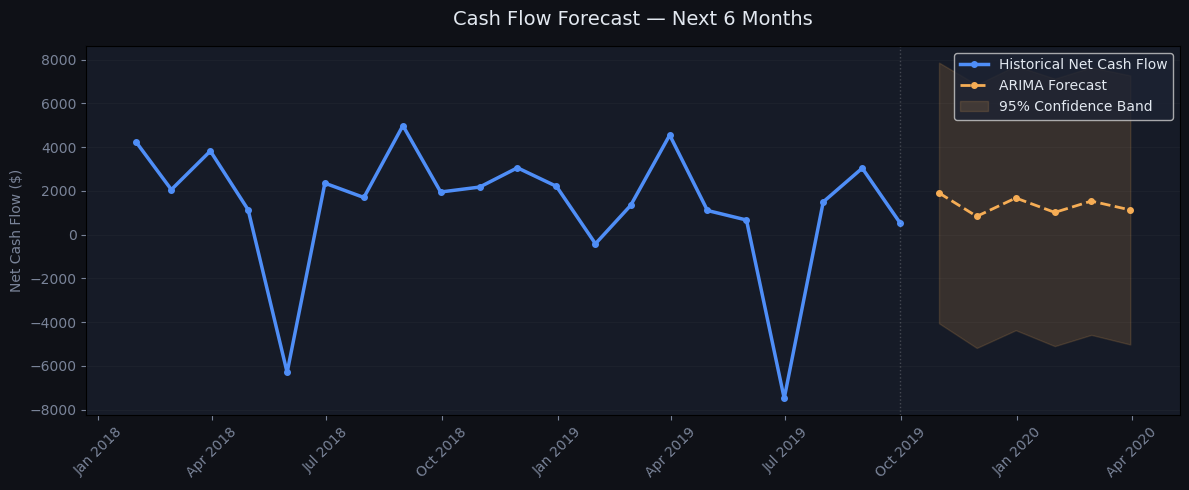

In [80]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 5))

# Historical line
ax.plot(monthly.index, monthly['net'], 
        color='#4f8ef7', linewidth=2.5, 
        marker='o', markersize=4, label='Historical Net Cash Flow')

# Forecast line
ax.plot(forecast_mean.index, forecast_mean, 
        color='#f6ad55', linewidth=2, 
        linestyle='--', marker='o', markersize=4, label='ARIMA Forecast')

# Confidence band
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                color='#f6ad55', alpha=0.15, label='95% Confidence Band')

# Divider line
ax.axvline(monthly.index[-1], color='white', alpha=0.2, linestyle=':', linewidth=1)

# Styling
ax.set_facecolor('#161b27')
fig.patch.set_facecolor('#0f1117')
ax.tick_params(colors='#7a8499')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.set_title('Cash Flow Forecast — Next 6 Months', 
             color='#e2e8f0', fontsize=14, pad=15)
ax.set_ylabel('Net Cash Flow ($)', color='#7a8499')
ax.legend(facecolor='#1d2333', labelcolor='#e2e8f0', framealpha=0.8)
ax.grid(axis='y', color='#ffffff', alpha=0.04, linewidth=0.5)

plt.tight_layout()
plt.savefig('../outputs/cashflow_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
